In [3]:
from torchvision.datasets import CocoDetection
from torchvision import transforms as T

dataset = CocoDetection(
    root='../Final_Project/dataset/val2017',
    annFile='../Final_Project/dataset/annotations/instances_val2017.json',
    transform=T.ToTensor()
)


loading annotations into memory...
Done (t=0.37s)
creating index...
index created!


loading annotations into memory...
Done (t=0.44s)
creating index...
index created!


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


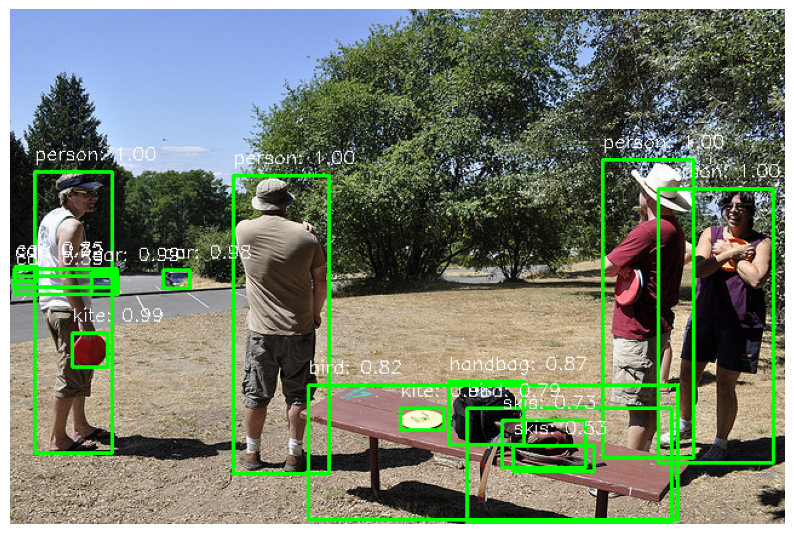

In [4]:
import torch
import torchvision
from torchvision.datasets import CocoDetection
from torchvision import transforms as T
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import cv2
import numpy as np

# ---------- Step 1: Define COCO Classes ----------
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag',
    'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite',
    'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana',
    'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table',
    'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock',
    'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

# ---------- Step 2: Load Dataset ----------
transform = T.Compose([T.ToTensor()])

coco_dataset = CocoDetection(
    root='../Final_Project/dataset/val2017',
    annFile='../Final_Project/dataset/annotations/instances_val2017.json',
    transform=transform
)

data_loader = DataLoader(
    coco_dataset,
    batch_size=1,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x))
)

# ---------- Step 3: Load Pretrained Model ----------
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# ---------- Step 4: Visualization Function ----------
def visualize_prediction(img_tensor, prediction, threshold=0.5):
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img * 255).astype(np.uint8).copy()

    for box, label, score in zip(prediction['boxes'], prediction['labels'], prediction['scores']):
        if score < threshold:
            continue
        box = box.int().cpu().numpy()
        label_text = f"{COCO_INSTANCE_CATEGORY_NAMES[label]}: {score:.2f}"
        cv2.rectangle(img, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)
        cv2.putText(img, label_text, (box[0], box[1] - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

# ---------- Step 5: Run Inference + Show ----------
with torch.no_grad():
    for imgs, _ in data_loader:
        img = imgs[0].to(device)
        prediction = model([img])[0]
        visualize_prediction(img, prediction)
        break  # remove this line to loop through more images

In [5]:
!pip install tqdm

Defaulting to user installation because normal site-packages is not writeable


In [6]:
from torch.utils.data import DataLoader
from pycocotools.cocoeval import COCOeval
from pycocotools.coco import COCO
import os
import json
from tqdm import tqdm

# -------- Setup -------- #
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model.to(device)
model.eval()

# -------- Load COCO Val Dataset -------- #
transform = T.Compose([T.ToTensor()])
coco_val = CocoDetection(
    root='../Final_Project/dataset/val2017',
    annFile='../Final_Project/dataset/annotations/instances_val2017.json',
    transform=transform
)
data_loader = DataLoader(coco_val, batch_size=1, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

# -------- Collect Model Predictions -------- #
results = []
image_ids = []

print("Running inference...")
for img_idx, (imgs, targets) in enumerate(tqdm(data_loader)):
    img = imgs[0].to(device)
    img_id = coco_dataset.ids[img_idx]  # Get COCO image ID

    with torch.no_grad():
        prediction = model([img])[0]

    for box, label, score in zip(prediction['boxes'], prediction['labels'], prediction['scores']):
        box = box.tolist()
        x, y, x2, y2 = box
        w = x2 - x
        h = y2 - y

        results.append({
            "image_id": int(img_id),
            "category_id": int(label),
            "bbox": [x, y, w, h],
            "score": float(score)
        })


loading annotations into memory...
Done (t=0.39s)
creating index...
index created!
Running inference...


100%|███████████████████████████████████████| 5000/5000 [05:22<00:00, 15.49it/s]


In [7]:
# -------- Save Predictions to File -------- #
os.makedirs("eval_output", exist_ok=True)
pred_file = "eval_output/coco_predictions.json"
with open(pred_file, "w") as f:
    json.dump(results, f, indent=4)

# -------- Evaluate using pycocotools -------- #
print("Evaluating with COCO API...")
coco_gt = COCO('../Final_Project/dataset/annotations/instances_val2017.json')
coco_dt = coco_gt.loadRes(pred_file)

coco_eval = COCOeval(coco_gt, coco_dt, iouType='bbox')
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

Evaluating with COCO API...
loading annotations into memory...
Done (t=0.27s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.97s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=15.91s).
Accumulating evaluation results...
DONE (t=2.86s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.370
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.585
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.398
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.211
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.403
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.482
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.307
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.485
 Average Recall     (AR) @[ IoU=0.50

In [8]:
import time

times = []

with torch.no_grad():
    for img_idx, (imgs, _) in enumerate(data_loader):
        img = imgs[0].to(device)

        start = time.perf_counter()
        prediction = model([img])[0]
        end = time.perf_counter()

        elapsed = end - start
        times.append(elapsed)

        # (Optional) print progress for first few images
        if img_idx < 5:
            print(f"Image {img_idx}: {elapsed:.4f} seconds")

        if img_idx == 99:  # Test on 100 images
            break


Image 0: 0.0737 seconds
Image 1: 0.0549 seconds
Image 2: 0.0591 seconds
Image 3: 0.0585 seconds
Image 4: 0.0626 seconds


In [9]:
import numpy as np

times = np.array(times)
print(f"\nAverage Inference Time per Image: {times.mean():.4f} seconds")
print(f"Median: {np.median(times):.4f}, Min: {times.min():.4f}, Max: {times.max():.4f}")



Average Inference Time per Image: 0.0583 seconds
Median: 0.0590, Min: 0.0453, Max: 0.0737


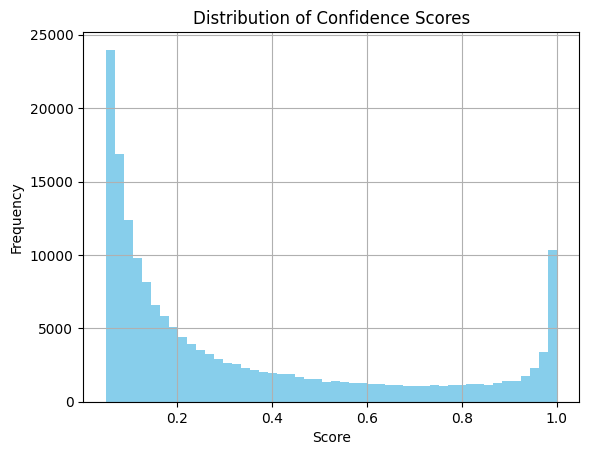

In [10]:
all_scores = [r['score'] for r in results]
plt.hist(all_scores, bins=50, color='skyblue')
plt.title('Distribution of Confidence Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


In [11]:
coco_eval.summarize()
for idx, cat_id in enumerate(coco_gt.getCatIds()):
    cat_name = coco_gt.loadCats(cat_id)[0]["name"]
    print(f"{cat_name:<20}: AP = {coco_eval.eval['precision'][:, idx, 0, 0, 2].mean():.4f}")


 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.370
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.585
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.398
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.211
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.403
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.482
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.307
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.485
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.509
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.315
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.545
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.647
person              : AP = 0.9286
bicycl

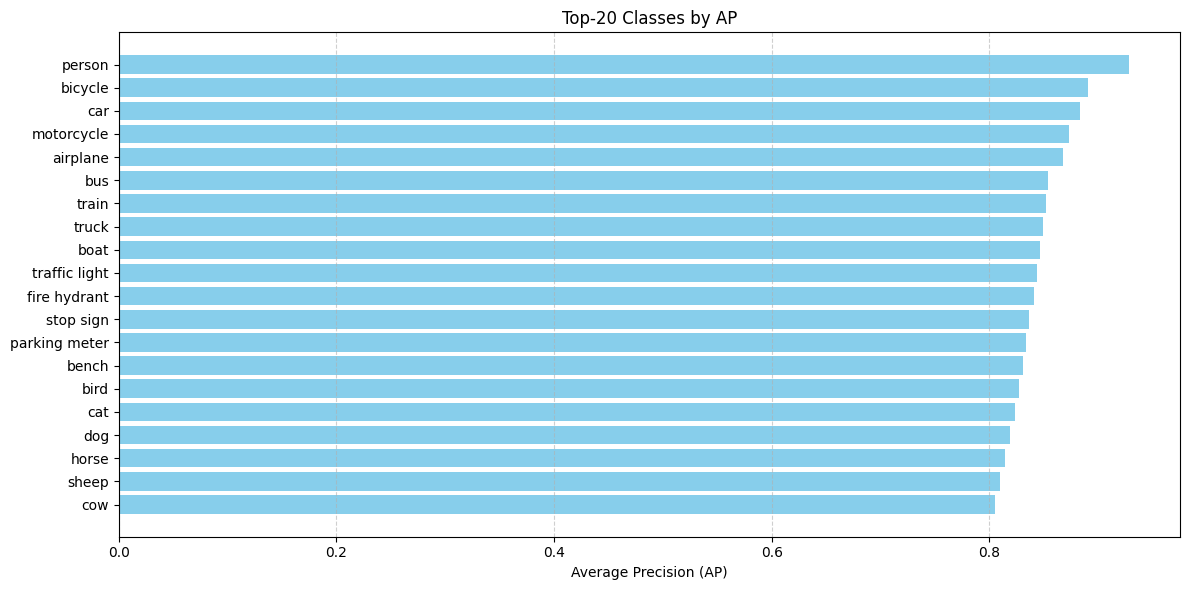

In [35]:
import matplotlib.pyplot as plt

# Prepare data
labels = [
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train',
    'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow'
]
aps = [
    0.9286, 0.8904, 0.8832, 0.8733, 0.8678, 0.8536, 0.8516, 0.8496, 0.8464, 0.8438,
    0.8406, 0.8362, 0.8334, 0.8308, 0.8269, 0.8234, 0.8190, 0.8140, 0.8096, 0.8053
]

plt.figure(figsize=(12, 6))
bars = plt.barh(labels[::-1], aps[::-1], color='skyblue')
plt.xlabel("Average Precision (AP)")
plt.title("Top-20 Classes by AP")
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
